In [7]:
import cv2
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

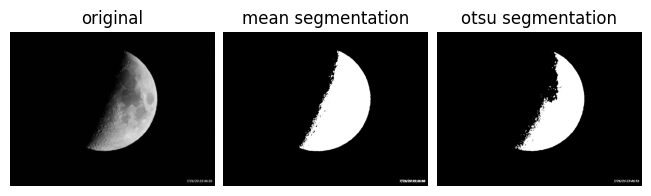

In [9]:
img = cv2.imread('halfmoon.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

thresh = img.mean()
img_segment = img > thresh

thresh2 = threshold_otsu(img)
img_segment2 = img > thresh2

plt.subplots(1,3, layout='constrained')
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('original')
plt.subplot(1, 3, 2)
plt.imshow(img_segment, cmap='gray')
plt.axis('off')
plt.title('mean segmentation')
plt.subplot(1, 3, 3)
plt.imshow(img_segment2, cmap='gray')
plt.axis('off')
plt.title('otsu segmentation')

plt.show()

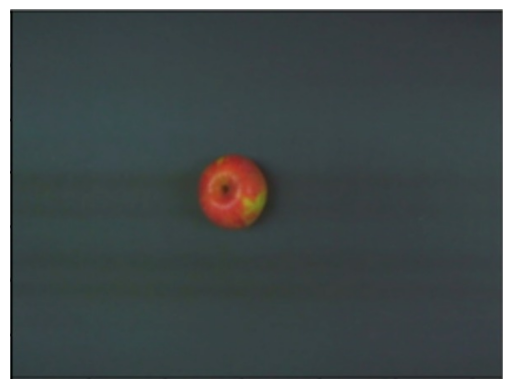

In [13]:
apel = cv2.imread('apel.jpeg')
b, g, r = cv2.split(apel)
apel_rgb = cv2.merge([r,g,b])
plt.imshow(apel_rgb)
plt.axis('off')
plt.show()

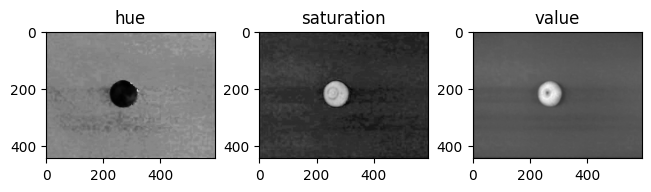

In [14]:
from sklearn.cluster import KMeans
apel_hsv = cv2.cvtColor(apel_rgb, cv2.COLOR_RGB2HSV)
h,s,v = cv2.split(apel_hsv)
plt.subplots(1,3, layout='constrained')
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title("hue")
plt.subplot(1,3,2)
plt.imshow(s,cmap='gray')
plt.title('saturation')
plt.subplot(1,3,3)
plt.imshow(v,cmap='gray')
plt.title('value')
plt.show()

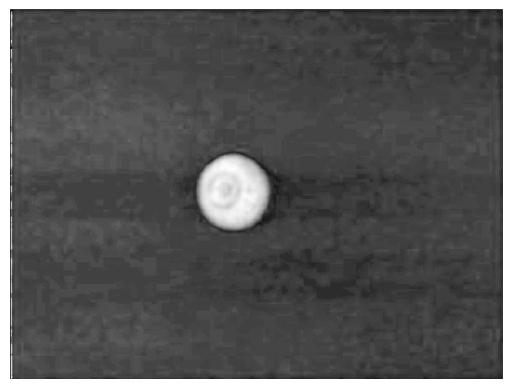

In [15]:
apel_gray = (0.7*s + 0.3*v)
plt.imshow(apel_gray, cmap='gray')
plt.axis('off')
plt.show()

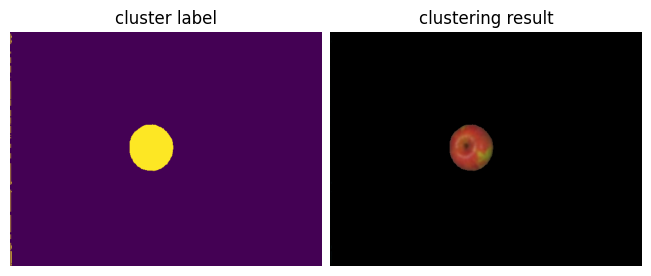

In [19]:
X = apel_gray.flatten().reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
label = kmeans.predict(X)
cluster = label.reshape(apel_gray.shape)

result = cv2.merge([r*cluster, g*cluster, b*cluster])
plt.subplots(1, 2, layout='constrained')
plt.subplot(1,2,1)
plt.imshow(cluster)
plt.title('cluster label')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(result)
plt.axis('off')
plt.title('clustering result')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..11677.180909791541].


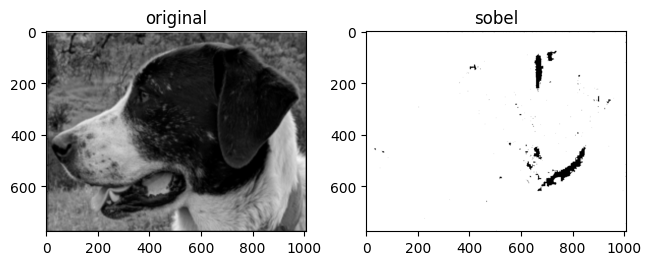

In [21]:
import numpy as np
dog = cv2.imread('dog.jpeg')
dog_x = cv2.Sobel(dog, cv2.CV_64F, 1, 0, ksize=5)
dog_y = cv2.Sobel(dog, cv2.CV_64F, 0, 1, ksize=5)
dog_sobel = np.sqrt(dog_x**2 + dog_y**2)
plt.subplots(1,2,layout='constrained')
plt.subplot(1,2,1)
plt.imshow(dog)
plt.title('original')
plt.subplot(1,2,2)
plt.imshow(dog_sobel, cmap='gray')
plt.title('sobel')
plt.show()